# Assignment 2 - Numbers to Neurons

---
> Complete each question below. Write theory answers in Markdown cells and code in code cells.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## Q1 - Perceptrons and Sigmoid Neurons

### Q1a - NAND Perceptron

Write a Python class using NumPy that implements a **NAND logic gate** using a single perceptron. Your implementation must use **vectorized operations** (no explicit `for` loops in the activation function) to process an input matrix of shape `(N, 2)` and return the corresponding binary outputs.

Mathematically determine and set the correct weights and bias within your code.

In [ ]:
#code here
import numpy as np

class NANDPerceptron:
    def __init__(self):
        self.weights = np.array([-2.0, -2.0])
        self.bias = 3.0

    def predict(self, X):
        z = X @ self.weights + self.bias
        return (z > 0).astype(int)


# Test
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

nand = NANDPerceptron()
print(nand.predict(X))

[1 1 1 0]


### Q1b - Perceptron Sensitivity

Explain precisely why a tiny change in one weight can cause **chaos** in a perceptron network. What property of the perceptron makes this happen?

> **Your answer:**
perceptron has a threshold function, and even if we change the weight slightly, the weighted sum can cross the threshold, and the output suddenly jumps from 0 to 1 or 1 to 0,  which can cause chaos in the network.

### Q1c - Sigmoid to Perceptron Limit

Suppose you multiply all the weights and bias of a sigmoid neuron by a positive constant c > 0.

1. As c approaches what value will this sigmoid neuron behave exactly like a classic perceptron? Why mathematically?
2. Explain in 2-3 lines why we prefer sigmoid neurons over perceptrons.

> **Your answer:**
When all weights and biases are multiplied by a large positive constant c, the input becomes cz. As c approaches infinity, the sigmoid becomes increasingly steep and approaches a step function.

We prefer sigmoid neurons because they are differentiable and have smooth gradients, which allows gradient descent and backpropagation to work. Perceptrons have discontinuous outputs and cannot be trained efficiently with gradient-based methods.

---
## Q2 - The Quadratic Cost Function

$$C(w,b) = \frac{1}{2n} \sum_x \|y(x) - a\|^2$$

### Q2a - The Factor of 1/2

Why is there a factor of 1/2 in front? Derive why it is mathematically convenient when computing the derivative of C with respect to any weight w.

> **Your answer:**
The factor 1/2 is included for mathematical convenience. When differentiating the squared error term:
      d/dw[1/2(y-a)^2]

the factor of 2 produced by the power rule cancels the 1/2, giving:
       (a-y)da/dw

This simplifies gradient calculations without changing the location of the minimum

### Q2b - Computing C by Hand

A network has two training examples:
- Example 1: output = 0.9, target = 1.0
- Example 2: output = 0.3, target = 0.0

Compute C by hand and explain what the value tells you about network performance.

> **Your answer:**
**Your answer:**

For the first example:

(1.0 - 0.9)^2 = 0.01

For the second example:

(0.0 - 0.3)^2 = 0.09

Total squared error:

0.01 + 0.09 = 0.10

Since n = 2,

C = (1/(2×2)) × 0.10 = 0.025

Therefore, the cost is 0.025.

This is a small cost value, which means the network predictions are close to the target values and the network is performing reasonably well.

In [ ]:
# Verify your hand computation
outputs = np.array([0.9, 0.3])
targets = np.array([1.0, 0.0])

C_val = np.sum((targets - outputs)**2)/(2*len(outputs))  # TODO: compute C
print(f'C = {C_val}')

C = 0.024999999999999998


### Q2c - Cost vs Accuracy

Explain why we use a cost function and do **not** directly maximise classification accuracy.

> **Your answer:**
**Your answer:**

Accuracy only tells whether a prediction is correct or incorrect. It does not measure how confident or close the prediction is to the target value. Cost functions provide a smooth numerical measure of error, allowing gradient descent to compute gradients and improve the network parameters. Accuracy is not differentiable, so it cannot be directly optimised using gradient-based learning methods.

### Q2d - Absolute Error vs Squared Error

An alternative cost is the absolute error: C = (1/n) * sum |y(x) - a|.

Explain **one mathematical problem** with using absolute error instead of squared error, specifically when doing gradient descent.

> **Your answer:**
**Your answer:**

The absolute error function is not differentiable when the prediction equals the target. Since gradient descent relies on derivatives to determine how parameters should be updated, the non-differentiability of absolute error makes optimisation more difficult. Squared error is smooth and differentiable everywhere, which makes gradient-based learning easier.

---
## Q3 - Gradient Descent on a Toy Cost Function

$$C(w, b) = (w - 3)^2 + 2(b - 1)^2$$

### Q3a - Minimum by Inspection

By inspection, what values of w and b minimise C? What is the minimum value of C? Explain your reasoning without calculus.

> **Your answer:**

The cost function is the sum of two squared terms. Since squares are always non-negative, the smallest possible value occurs when both squared terms are zero.

(w - 3)^2 = 0 when w = 3

(b - 1)^2 = 0 when b = 1

Therefore, the minimum occurs at:

w = 3, b = 1

and the minimum value of the cost function is:

C = 0

### Q3b - Two Steps by Hand

Compute dC/dw and dC/db. Starting from (w, b) = (0, 0) with learning rate eta = 0.1, show the first two gradient descent update steps by hand. Where does the parameter vector end up after step 2?

> **Your answer:**


dC/dw = 2(w - 3)

dC/db = 4(b - 1)

Starting from:

w = 0, b = 0, η = 0.1

Step 1:

dC/dw = -6
dC/db = -4

w = 0 - 0.1(-6) = 0.6
b = 0 - 0.1(-4) = 0.4

Step 2:

dC/dw = 2(0.6 - 3) = -4.8
dC/db = 4(0.4 - 1) = -2.4

w = 0.6 - 0.1(-4.8) = 1.08
b = 0.4 - 0.1(-2.4) = 0.64

After two steps, the parameter vector is:

(w, b) = (1.08, 0.64)

In [ ]:
def cost(w, b):
    return (w - 3)**2 + 2*(b - 1)**2

def grad_cost(w, b):
    dw = 2*(w - 3)  # TODO
    db = 4*(b - 1)  # TODO
    return dw, db

# Verify your hand calculation
eta = 0.1
w, b = 0.0, 0.0
for step in range(1, 3):
    dw, db = grad_cost(w, b)
    w = w - eta * dw
    b = b - eta * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=0.6000, b=0.4000, C=6.4800
Step 2: w=1.0800, b=0.6400, C=3.9456


### Q3c - Too-Large Learning Rate

If you set eta = 0.6, what goes wrong on the b update? Show numerically. What does this tell you about learning rate selection?

> **Your answer:**
**Your answer:**

With a learning rate of 0.6, the updates become too large. Starting from b = 0:

First update:

b = 0 - 0.6(-4) = 2.4

Second update:

b = 2.4 - 0.6(5.6) = -0.96

Instead of moving smoothly toward the minimum at b = 1, the parameter jumps past it and oscillates. This is called overshooting. A learning rate that is too large can prevent convergence and may even cause divergence.

In [ ]:
eta_bad = 0.6
w, b = 0.0, 0.0
for step in range(1, 5):
    dw, db = grad_cost(w, b)
    w = w - eta_bad * dw
    b = b - eta_bad * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=3.6000, b=2.4000, C=4.2800
Step 2: w=2.8800, b=-0.9600, C=7.6976
Step 3: w=3.0240, b=3.7440, C=15.0596
Step 4: w=2.9952, b=-2.8416, C=29.5158


---
## Q4 - Sigmoid Neuron: Implementation and Visualisation

In [ ]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def forward(self, x):
        z = np.dot(self.weights, x) + self.bias
        return 1/(1 + np.exp(-z))

    def numerical_gradient(self, x, h=1e-5):

        grad_weights = np.zeros_like(self.weights)

        for i in range(len(self.weights)):

            original = self.weights[i]

            self.weights[i] = original + h
            f_plus = self.forward(x)

            self.weights[i] = original - h
            f_minus = self.forward(x)

            grad_weights[i] = (f_plus - f_minus)/(2*h)

            self.weights[i] = original

        original_bias = self.bias

        self.bias = original_bias + h
        f_plus = self.forward(x)

        self.bias = original_bias - h
        f_minus = self.forward(x)

        grad_bias = (f_plus - f_minus)/(2*h)

        self.bias = original_bias

        return grad_weights, grad_bias

### Q4a - Forward Pass and Gradients

For weights=[2, -1] and bias=0.5, compute the output and all gradients at x=[1, 1]. Explain what the gradient w.r.t. w1 means in plain English.

In [ ]:
neuron = SigmoidNeuron(weights=[2, -1], bias=0.5)
x = np.array([1.0, 1.0])

output = neuron.forward(x)
grad_w, grad_b = neuron.numerical_gradient(x)

print(f'Output:        {output}')
print(f'd(output)/dw1: {grad_w[0]:.6f}')
print(f'd(output)/dw2: {grad_w[1]:.6f}')
print(f'd(output)/db:  {grad_b:.6f}')

Output:        0.8175744761936437
d(output)/dw1: 0.149146
d(output)/dw2: 0.149146
d(output)/db:  0.149146


**Explanation of gradient w.r.t. w1:**

> **Your answer:**
**Your answer:**

z = 2(1) + (-1)(1) + 0.5 = 1.5

The neuron output is:

a = sigmoid(1.5) ≈ 0.8176

The sigmoid derivative is:

sigma'(1.5) = 0.8176(1 - 0.8176) ≈ 0.1491

Therefore:

da/dw1 = 0.1491
da/dw2 = 0.1491
da/db = 0.1491

The gradient with respect to w1 tells us how much the neuron output changes when w1 is changed slightly. A positive gradient means increasing w1 will increase the output.

### Q4b - Plot sigma(z) and sigma'(z)

Plot sigma(z) and its derivative sigma'(z) = sigma(z)(1 - sigma(z)) for z in [-10, 10].

- At what value of z is the gradient largest?
- What happens as z approaches +/- infinity and why is this a problem (vanishing gradient)?

> **Your answer:**

The derivative of the sigmoid is largest at z = 0.

At z = 0:

sigma(z) = 0.5

and

sigma'(z) = 0.25

which is the maximum possible gradient.

As z approaches positive or negative infinity, the sigmoid saturates near 1 or 0 and the derivative approaches zero. This causes the vanishing gradient problem because weight updates become extremely small, slowing or preventing learning in deep networks.

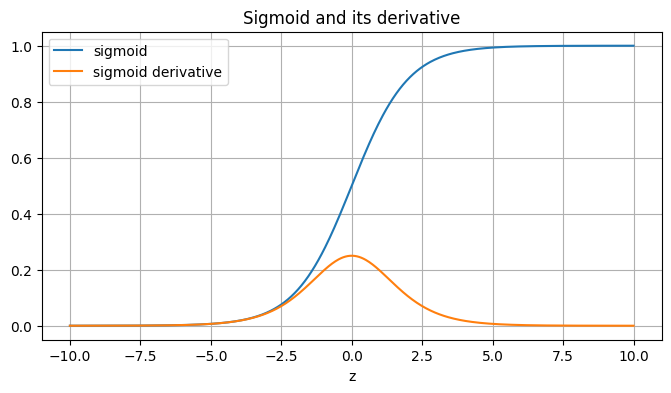

In [ ]:
z = np.linspace(-10, 10, 500)

sigma = 1/(1+np.exp(-z))
sigma_prime = sigma*(1-sigma)

plt.figure(figsize=(8, 4))
plt.plot(z, sigma, label='sigmoid')
plt.plot(z, sigma_prime, label='sigmoid derivative')

plt.xlabel('z')
plt.title('Sigmoid and its derivative')
plt.legend()
plt.grid(True)
plt.show()

### Q4c - Is sigma(100z) basically a perceptron?

A classmate claims: 'a sigmoid neuron with weights multiplied by 100 is basically the same as a perceptron.'

Plot sigma(100z) vs sigma(z) vs the step function. Is the claim correct? Under what condition does it break down?

> **Your answer:**

The claim is approximately correct. Multiplying the weights and bias by 100 makes the sigmoid function extremely steep, so it closely resembles a step function.

For positive z, sigma(100z) is very close to 1.

For negative z, sigma(100z) is very close to 0.

However, it is not exactly a perceptron because the sigmoid remains continuous and differentiable. The approximation breaks down near z = 0, where the sigmoid still transitions smoothly instead of making an instantaneous jump.

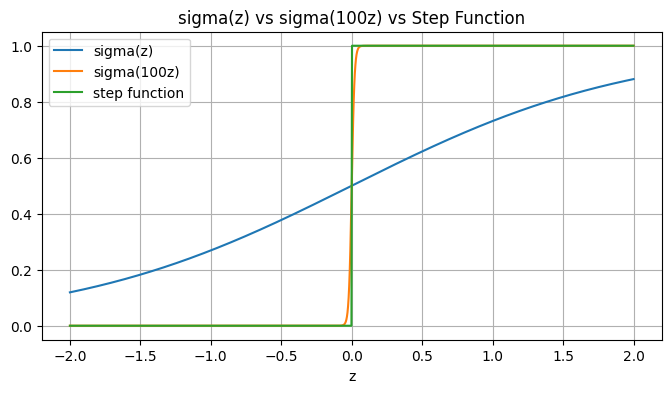

In [ ]:
z = np.linspace(-2, 2, 1000)

sigma_z = 1/(1+np.exp(-z))
sigma_100z = 1/(1+np.exp(-100*z))
step = (z >= 0).astype(int)

plt.figure(figsize=(8, 4))

plt.plot(z, sigma_z, label='sigma(z)')
plt.plot(z, sigma_100z, label='sigma(100z)')
plt.plot(z, step, label='step function')

plt.title('sigma(z) vs sigma(100z) vs Step Function')
plt.xlabel('z')
plt.legend()
plt.grid(True)
plt.show()

---
## Q5 - Gradient Descent on a Toy Regression Problem

A single-layer network (one input, one output, no activation) must learn y = 3x + 1.

In [ ]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

### Q5a - Analytical Gradients + Full-Batch GD

Derive dC/dw and dC/db analytically (show algebra). Implement full-batch GD with eta = 0.01 for 200 epochs. Plot the loss curve. Do w and b converge to 3 and 1?

**Derivation (show algebra):**

> **Your answer:**

For a prediction

y_hat = wx + b

the cost function is

C = (1/n) Σ(y_hat - y)^2

Differentiating with respect to w:

dC/dw = (2/n) Σ(y_hat - y)x

Differentiating with respect to b:

dC/db = (2/n) Σ(y_hat - y)

These gradients are used by gradient descent to update the parameters.

In [ ]:
w, b = 0.0, 0.0
eta = 0.01
losses = []

for epoch in range(200):

    y_pred = w * X_train + b

    loss = np.mean((y_pred - y_train)**2)

    dw = (2/len(X_train)) * np.sum((y_pred - y_train) * X_train)
    db = (2/len(X_train)) * np.sum(y_pred - y_train)

    w = w - eta * dw
    b = b - eta * db

    losses.append(loss)

### Q5b - SGD with Mini-Batch Size = 1

Implement SGD with batch size 1. Train 200 epochs with eta = 0.01. Plot the loss curve. How does it differ from full-batch? Explain in terms of gradient quality and noise.

> **Your answer:**

The SGD loss curve is noisier than the full-batch loss curve because each update uses only one training example. The gradient estimate therefore contains noise and varies from step to step.

Full-batch gradient descent uses all training examples and produces a smoother, more accurate gradient estimate. SGD is usually faster per update but follows a more irregular path toward the minimum.

In [ ]:
w, b = 0.0, 0.0
eta = 0.01
losses_sgd = []

for epoch in range(200):

    i = np.random.randint(len(X_train))

    x = X_train[i]
    y = y_train[i]

    y_pred = w * x + b

    dw = 2 * (y_pred - y) * x
    db = 2 * (y_pred - y)

    w = w - eta * dw
    b = b - eta * db

    loss = np.mean((w * X_train + b - y_train)**2)

    losses_sgd.append(loss)

### Q5c - Divergence with eta = 0.5

Set eta = 0.5 with full-batch GD. Show the loss curve and explain using the gradient formulas from Q5a why it diverges.

> **Your answer:**

When the learning rate is set to 0.5, the parameter updates become too large. Instead of moving gradually toward the minimum, the parameters overshoot it and jump back and forth. The gradients then become larger rather than smaller, causing the loss to increase instead of decrease. This behaviour is called divergence.

In [ ]:
w, b = 0.0, 0.0
eta = 0.5
losses_div = []

for epoch in range(50):

    y_pred = w * X_train + b

    loss = np.mean((y_pred - y_train)**2)

    dw = (2/len(X_train)) * np.sum((y_pred - y_train) * X_train)
    db = (2/len(X_train)) * np.sum(y_pred - y_train)

    w = w - eta * dw
    b = b - eta * db

    losses_div.append(loss)

    if not np.isfinite(loss):
        print(f'Diverged at epoch {epoch}')
        break

---
## Q6 - One-Hot to 4-Bit Binary Encoding Layer

A network classifies digits 0-9 with a 10-neuron one-hot output. Design a final **4-neuron layer** that converts this into a **4-bit binary** encoding (e.g. digit 5 outputs 0101). Specify the weight matrix and bias vector.

**Design and Reasoning:**

> **Your answer:**

Each output neuron represents one binary digit.

The mapping is:

0 -> 0000
1 -> 0001
2 -> 0010
3 -> 0011
4 -> 0100
5 -> 0101
6 -> 0110
7 -> 0111
8 -> 1000
9 -> 1001

The weight matrix has shape (4,10). Each column corresponds to the binary representation of the associated digit.

For example:

Digit 5 corresponds to column:

[0,1,0,1]^T

Digit 9 corresponds to column:

[1,0,0,1]^T

The bias vector can be set to zero.

In [ ]:
# TODO: define W (4x10) and b_enc (4,)
W = np.array([
    [0,0,0,0,0,0,0,0,1,1],
    [0,0,0,0,1,1,1,1,0,0],
    [0,0,1,1,0,0,1,1,0,0],
    [0,1,0,1,0,1,0,1,0,1]
], dtype=float)

b_enc = np.zeros(4)

def threshold(x):
    return (x >= 0.5).astype(int)

print('Digit | Output | Expected | OK?')
print('-' * 35)
for digit in range(10):
    one_hot = np.zeros(10)
    one_hot[digit] = 1.0
    out = threshold(W @ one_hot + b_enc)
    expected = format(digit, '04b')
    ok = 'OK' if ''.join(map(str, out)) == expected else 'FAIL'
    print(f'  {digit}   |  {out}  |  {expected}  | {ok}')

Digit | Output | Expected | OK?
-----------------------------------
  0   |  [0 0 0 0]  |  0000  | OK
  1   |  [0 0 0 1]  |  0001  | OK
  2   |  [0 0 1 0]  |  0010  | OK
  3   |  [0 0 1 1]  |  0011  | OK
  4   |  [0 1 0 0]  |  0100  | OK
  5   |  [0 1 0 1]  |  0101  | OK
  6   |  [0 1 1 0]  |  0110  | OK
  7   |  [0 1 1 1]  |  0111  | OK
  8   |  [1 0 0 0]  |  1000  | OK
  9   |  [1 0 0 1]  |  1001  | OK


---
## Q7 - Geometric Interpretation of 1D Gradient Descent

Consider C(v) as a function of a single scalar v.

1. Give a precise **geometric interpretation** of the update rule v = v - alpha * dC/dv.
2. How do the slope and the learning rate alpha physically dictate movement along the curve?

> **Your answer:**

The gradient dC/dv represents the slope of the cost function at the current point. Gradient descent moves in the opposite direction of this slope because that direction decreases the cost.

The learning rate alpha determines the step size. A larger alpha produces larger movements along the curve, while a smaller alpha produces more cautious movements. If alpha is too large, the algorithm may overshoot the minimum.

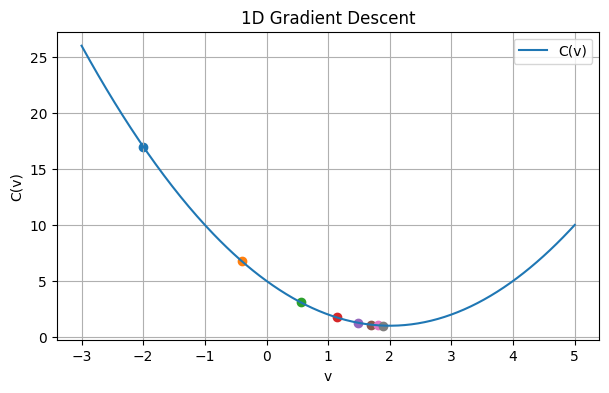

In [ ]:
v_vals = np.linspace(-3, 5, 300)
C_v = (v_vals - 2)**2 + 1

plt.figure(figsize=(7, 4))
plt.plot(v_vals, C_v, label='C(v)')

v = -2
eta = 0.2

for _ in range(8):
    c = (v - 2)**2 + 1
    plt.scatter(v, c)

    grad = 2*(v - 2)
    v = v - eta*grad

plt.xlabel('v')
plt.ylabel('C(v)')
plt.title('1D Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

---
## Q8 - Zero Hidden Layers: What Model Are You Really Training?

Suppose you remove all hidden layers, connecting 784 inputs directly to 10 outputs, trained with SGD.

1. What **mathematical model** have you effectively created?
2. Why is classification accuracy **fundamentally capped**?
3. What does this imply about the **necessity of hidden layers**?

> **Your answer:**

1. Removing all hidden layers creates a linear model. For classification, this is equivalent to multinomial logistic regression (or a linear classifier).

2. Classification accuracy is fundamentally limited because the model can only learn linear decision boundaries. Many real-world datasets are not linearly separable.

3. Hidden layers allow the network to learn nonlinear features and complex decision boundaries. This makes them essential for solving difficult tasks such as image recognition and natural language processing.